In [16]:
%load_ext autoreload
%autoreload 2

import sys
import os
import platform

import numpy as np
import pandas as pd

import matplotlib
# matplotlib.use('qt5agg')
import matplotlib.pyplot as plt
# from matplotlib import cm
import matplotlib.dates as mdates

from datetime import datetime

import ttu_tower.definitions as d

import windprofiles.lib.atmos as atmos

parent_dir = os.path.abspath('..')

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
from src import loader, generate_configs, plotting

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
print(loader.available_data())

['ds11Mar2014', 'ds14Dec2012', 'ds16Nov2013', 'ds18Mar2014', 'ds28Feb2014']


In [18]:
SELECTION = "ds11Mar2014"
_DATE = datetime.strptime(SELECTION[2:], "%d%b%Y")
DATE = _DATE.strftime("%B %#d, %Y" if platform.system() == "Windows" else "%B %-d, %Y")

In [19]:
df = loader.load(SELECTION)
dateformatter = mdates.DateFormatter("%H:%M", tz="US/Central")

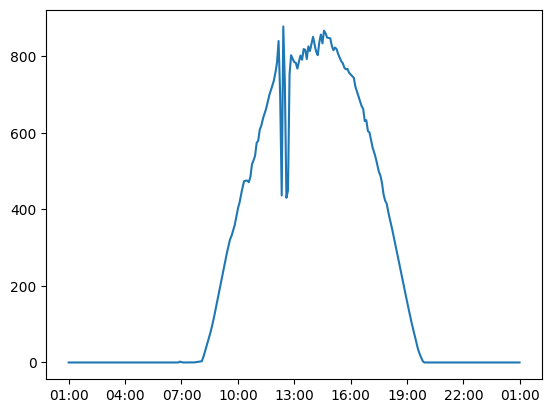

In [29]:
fig, ax = plt.subplots()
ax.plot(df["timestamp"], df["solar"])
ax.xaxis.set_major_formatter(dateformatter)
plt.show()

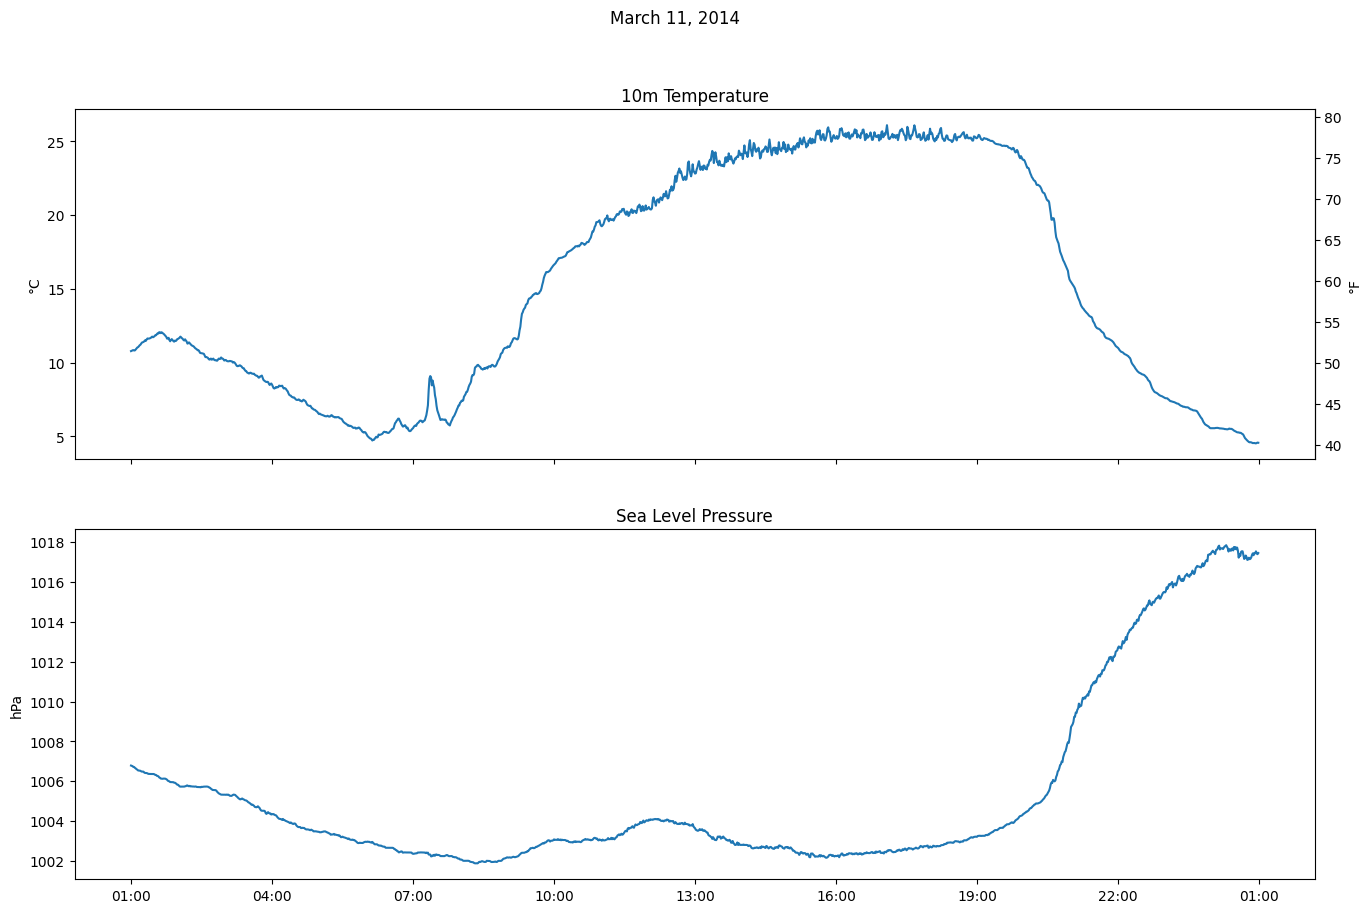

In [21]:
%matplotlib inline
T_f = lambda T_c: T_c * 1.8 + 32.
T_c = lambda T_f: (T_f - 32.) / 1.8
fig, (ax_t, ax_p) = plt.subplots(figsize=(16,10), nrows=2, sharex=True)
ax_t.plot(df["timestamp"], df["t_4_mean"]-273.15)
ax_t2 = ax_t.secondary_yaxis("right", functions=(T_f, T_c))
ax_t.xaxis.set_major_formatter(dateformatter)
ax_t.set_ylabel("°C")
ax_t2.set_ylabel("°F")
ax_p.plot(df["timestamp"], atmos.pressure_to_slp(df["p_4_mean"], d.LOCATION.elevation+d.ALL_HEIGHTS_DICT[4], d.LOCATION.g)*10) # type: ignore
ax_p.xaxis.set_major_formatter(dateformatter)
ax_p.set_ylabel("hPa")
ax_t.set_title("10m Temperature")
ax_p.set_title("Sea Level Pressure")
fig.suptitle(DATE)
plt.show()

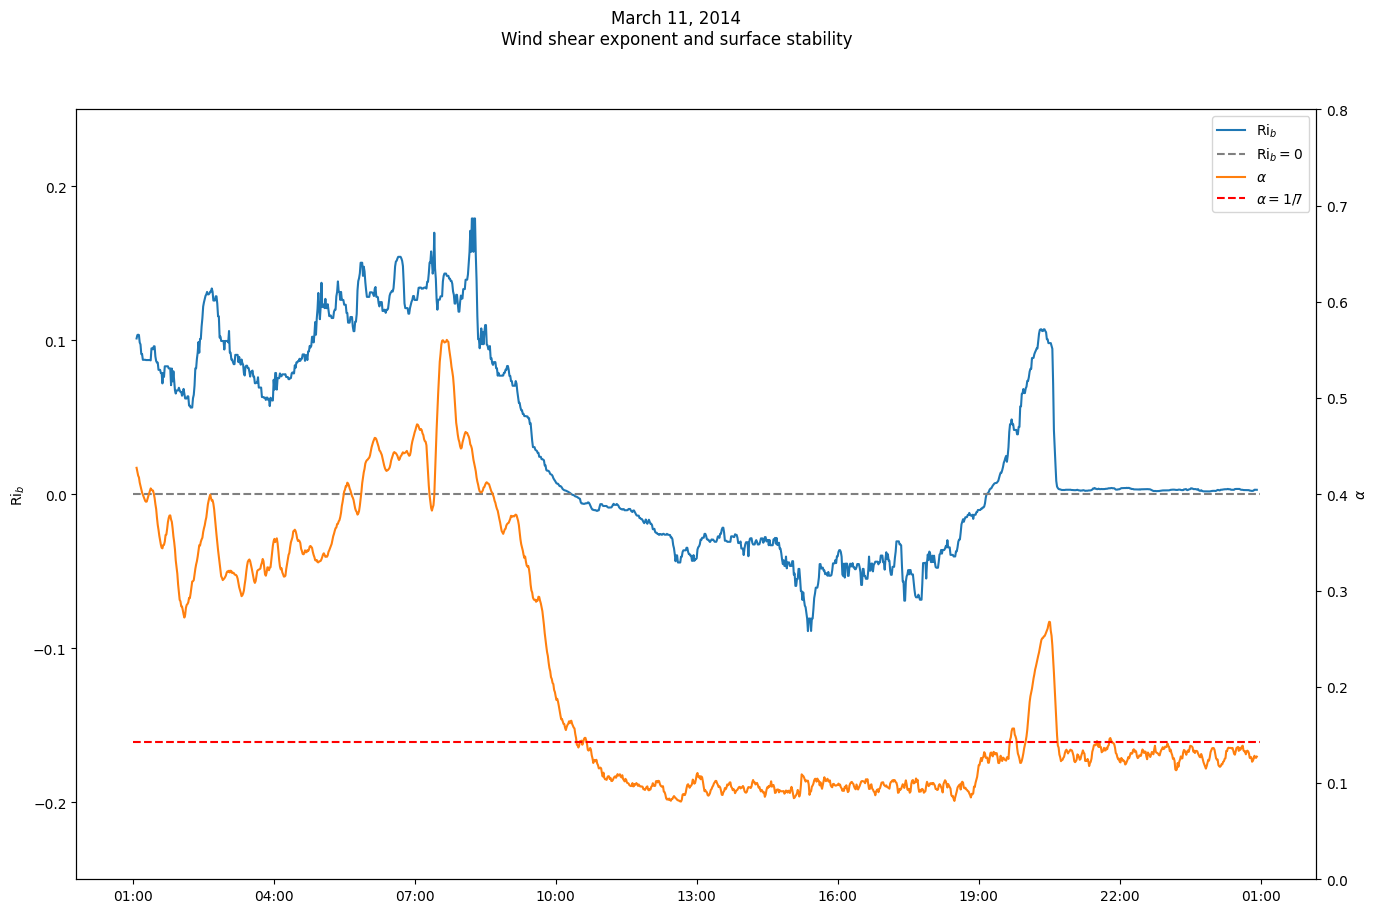

In [22]:
fig, ax = plt.subplots(figsize=(16,10))
plotting.plot_smoothed(ax, df["timestamp"], df["Rib_2-4"], window=10, method="median", label=r"Ri$_b$", color="tab:blue")
ax.set_ylim(-0.25,0.25)
ax.set_ylabel(r"Ri$_b$")
ax.plot([df["timestamp"].min(), df["timestamp"].max()], [0,0], label=r"Ri$_b=0$", color="gray", linestyle="dashed")
ax2 = ax.twinx()
plotting.plot_smoothed(ax2, df["timestamp"], df["alpha"], window=10, method="mean", label=r"$\alpha$", color="tab:orange")
ax2.set_ylim(0,0.8)
ax2.set_ylabel(r"$\alpha$")
ax2.plot([df["timestamp"].min(), df["timestamp"].max()], [1/7,1/7], label=r"$\alpha=1/7$", color="red", linestyle="dashed")
ax.xaxis.set_major_formatter(dateformatter)
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, loc="upper right")
fig.suptitle(f"{DATE}\nWind shear exponent and surface stability")
plt.show()

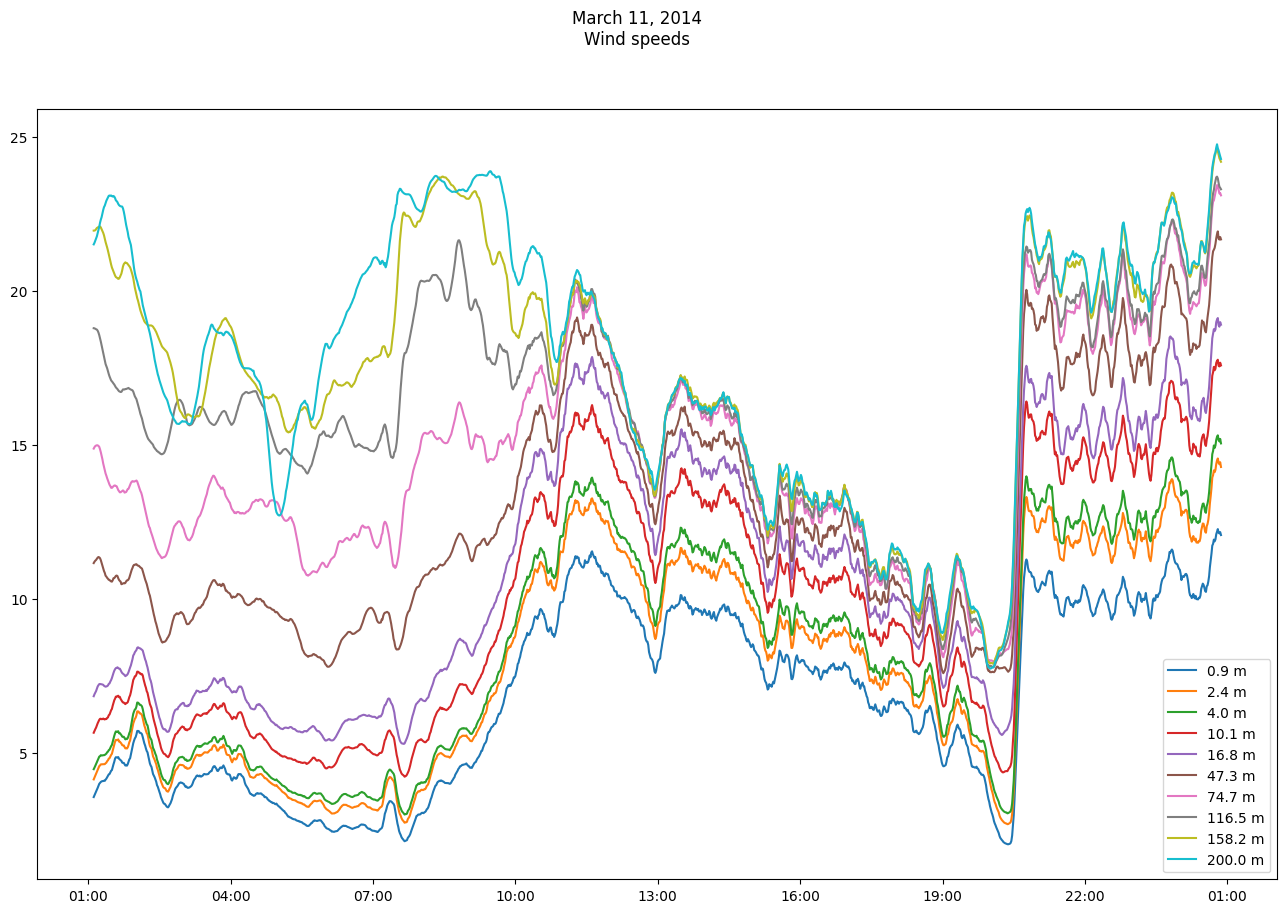

In [23]:
# %matplotlib widget
fig, ax = plt.subplots(figsize=(16,10))
for b, h in d.ALL_HEIGHTS_DICT.items():
    plotting.plot_smoothed(ax, df["timestamp"], df[f"ws_{b}_mean"], window=15, method="mean", label=f"{h} m")
ax.legend()
ax.xaxis.set_major_formatter(dateformatter)
fig.suptitle(f"{DATE}\nWind speeds")
plt.show()

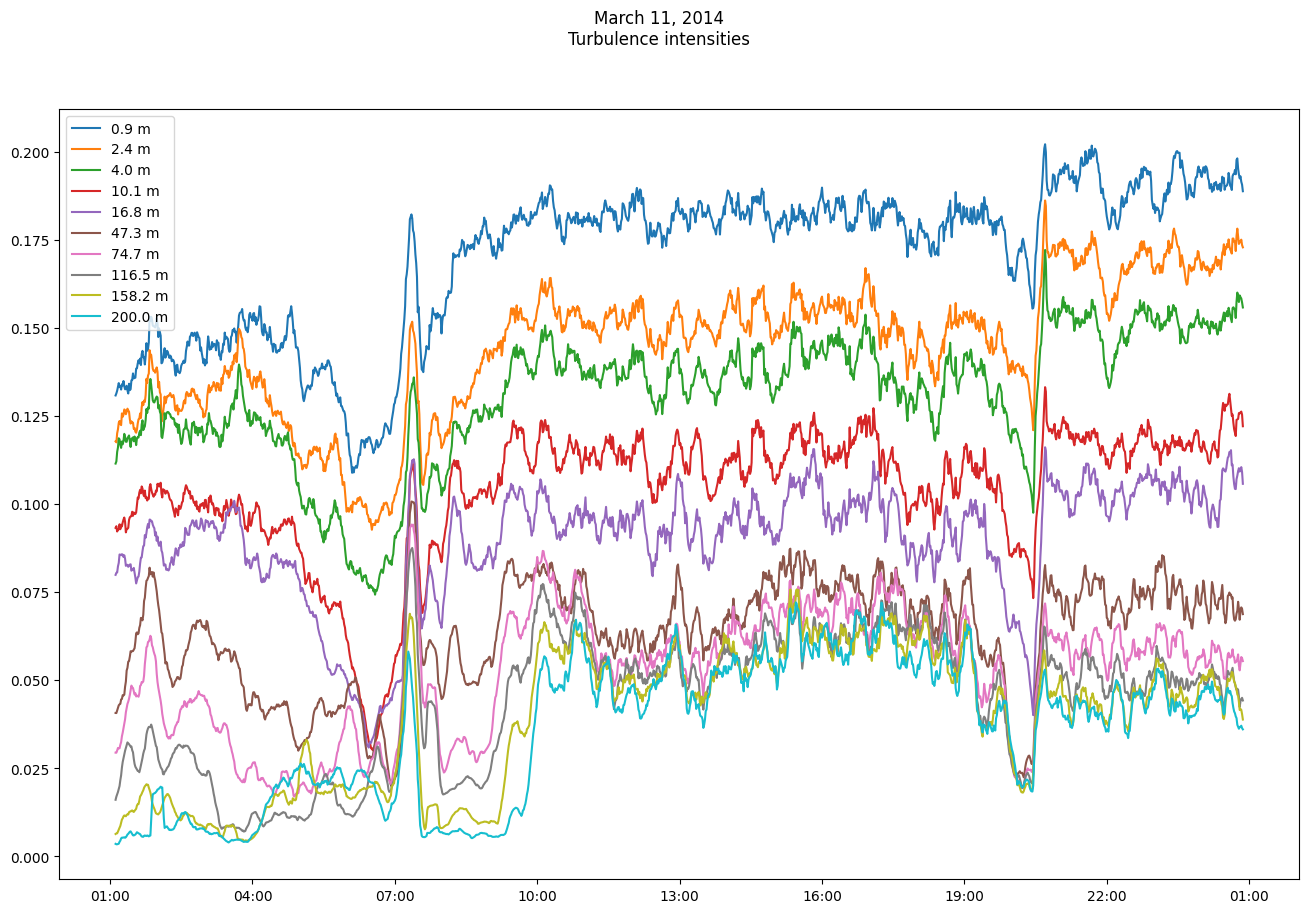

In [24]:
# %matplotlib widget
fig, ax = plt.subplots(figsize=(16,10))
for b, h in d.ALL_HEIGHTS_DICT.items():
    plotting.plot_smoothed(ax, df["timestamp"], df[f"ti_{b}"], window=15, method="mean", label=f"{h} m")
ax.legend()
ax.xaxis.set_major_formatter(dateformatter)
fig.suptitle(f"{DATE}\nTurbulence intensities")
plt.show()

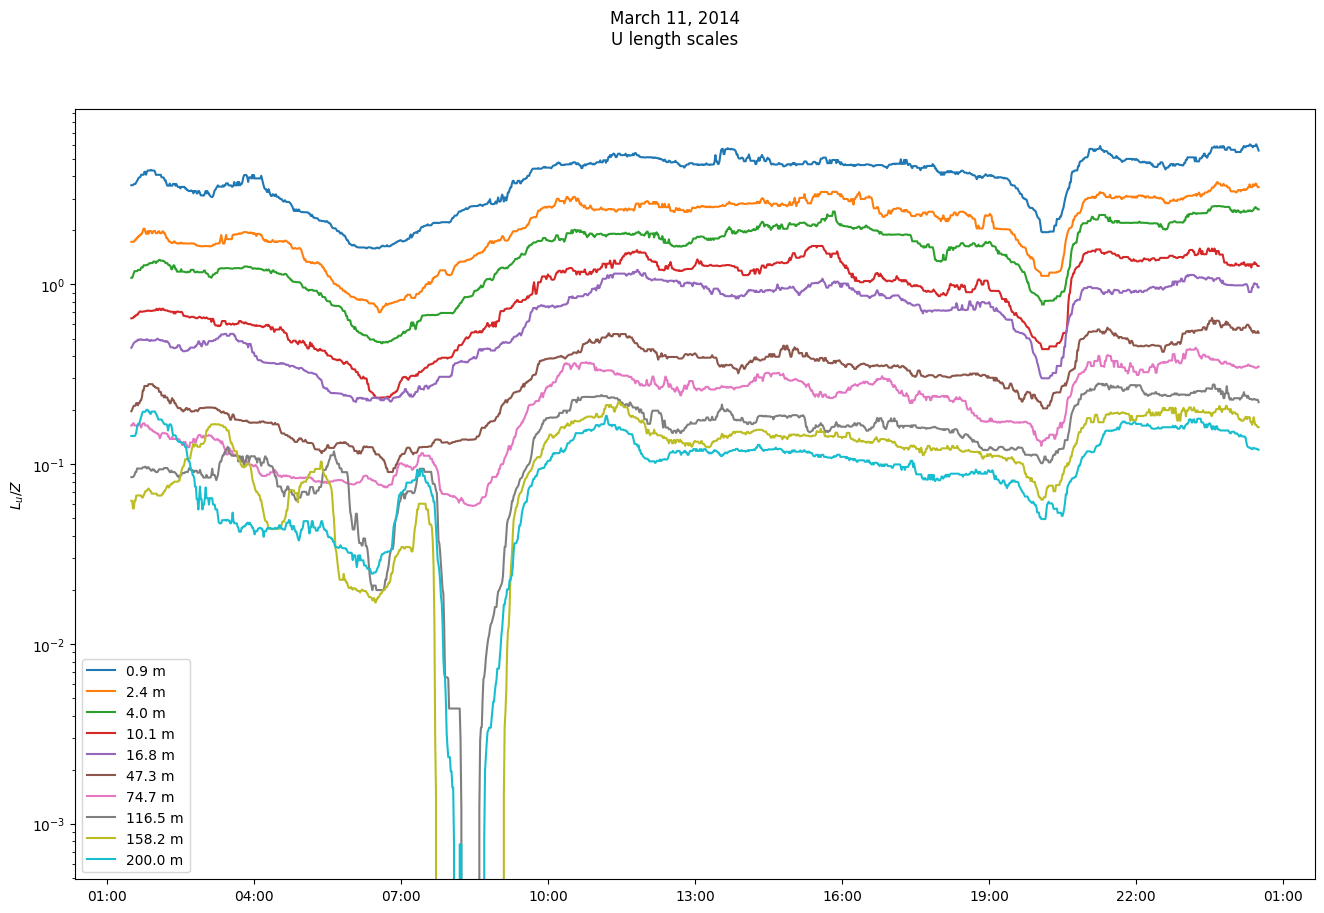

In [25]:
fig, ax = plt.subplots(figsize=(16,10))
for b, h in d.ALL_HEIGHTS_DICT.items():
    plotting.plot_smoothed(ax, df["timestamp"], df[f"ILS-efolding_u_{b}"]/d.ALL_HEIGHTS_DICT[b], window=60, method="median", label=f"{h} m")
ax.legend()
ax.set_yscale("log")
ax.set_ylabel(r"$L_u/Z$")
ax.xaxis.set_major_formatter(dateformatter)
fig.suptitle(f"{DATE}\nU length scales")
plt.show()

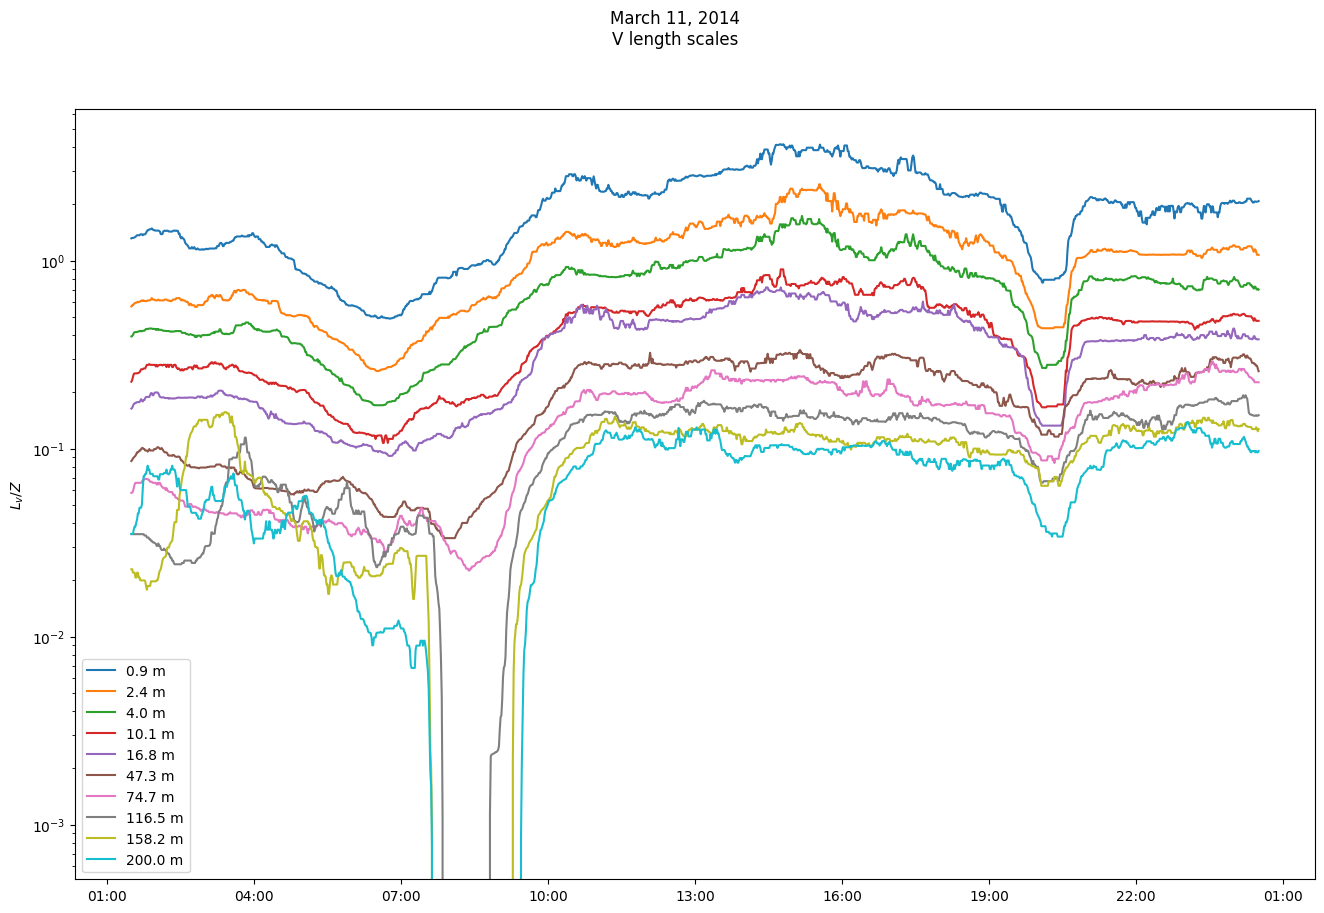

In [26]:
fig, ax = plt.subplots(figsize=(16,10))
for b, h in d.ALL_HEIGHTS_DICT.items():
    plotting.plot_smoothed(ax, df["timestamp"], df[f"ILS-efolding_v_{b}"]/d.ALL_HEIGHTS_DICT[b], window=60, method="median", label=f"{h} m")
ax.legend()
ax.set_yscale("log")
ax.set_ylabel(r"$L_v/Z$")
ax.xaxis.set_major_formatter(dateformatter)
fig.suptitle(f"{DATE}\nV length scales")
plt.show()

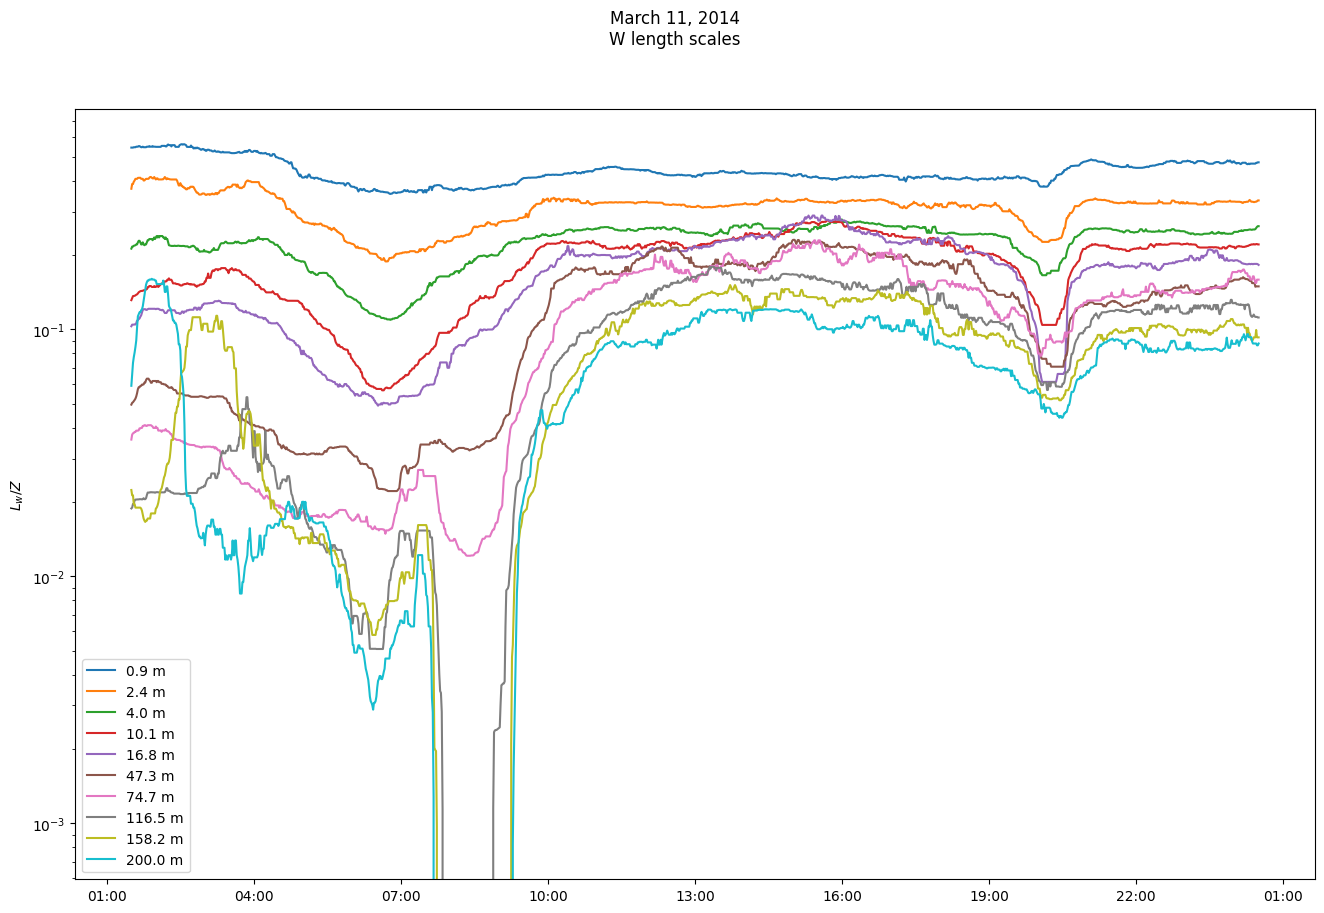

In [27]:
fig, ax = plt.subplots(figsize=(16,10))
for b, h in d.ALL_HEIGHTS_DICT.items():
    plotting.plot_smoothed(ax, df["timestamp"], df[f"ILS-efolding_w_{b}"]/d.ALL_HEIGHTS_DICT[b], window=60, method="median", label=f"{h} m")
ax.legend()
ax.set_yscale("log")
ax.set_ylabel(r"$L_w/Z$")
ax.xaxis.set_major_formatter(dateformatter)
fig.suptitle(f"{DATE}\nW length scales")
plt.show()

In [28]:
# Looks like the storm only starts around 9 pm (Mar 11, 2014) - should probably include data from the next morning.
# https://www.weather.gov/lub/events-2014-20140311-wind
# https://www.weather.gov/lub/events-2012
# https://www.weather.gov/lub/events-2013
# https://www.weather.gov/lub/events-2014